# Optimization Benchmark given different Perturbation to the Original Field
Ported from MATLAB: spectral_main.m + 6 helper .m files.

All operations are 2D spectral (surface only).
Uses JAX for JIT compilation, GPU acceleration, and auto-differentiation.

In [4]:
# Packages

import jax
# Enable 64-bit
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax import jit
import jaxopt
import matplotlib
# matplotlib.use('Agg')          # headless, no Tk
import matplotlib.pyplot as plt
import numpy as np
import os
import time
import tkinter as tk
from tkinter import filedialog
import scipy.io as sio
import sys
import dill

# For fourier transform
from numpy.fft import rfft2, irfft2

# Input subfiles
%reload_ext autoreload
%autoreload 2

# Parent Python_Spectral_Toy_model folder (two levels up from this notebook)
_nb_dir = os.getcwd()
sys.path.insert(0, os.path.abspath(os.path.join(_nb_dir, '..', '..')))
from physics_functions import calculate_surface_u, forward_ssh
from cost_functions import cost_function_fmin
from ssh_setup import ssh_setup
from perturbation_setup import build_all_perturbations, print_rms_table

# Group-C sweep lives in the same folder as this notebook
sys.path.insert(0, _nb_dir)
from perturbation_setup_group_C import build_group_C_perturbations




# Load the Data

In [5]:
import sys

print("Select an SSH data file (.mat)... Press Cancel to use default SSH_setup")
root = tk.Tk()
root.withdraw()

file_path = filedialog.askopenfilename(
    title="Select an SSH data file (.mat)",
    filetypes=[("MATLAB Data Files", "*.mat"), ("All Files", "*.*")]
)

mat_contents = sio.loadmat(file_path)
# Find the relevant array (expecting buoyancy 'bout')
key = 'bout'
b_s_data = mat_contents[key]
b_s = b_s_data[:, :, -1]
print(f"Loaded 3D buoyancy data from {file_path}, using the last period.")

# Normalization
b_s_normalized = b_s / jnp.max(jnp.abs(b_s))

Nx, Ny = b_s_normalized.shape
print(f"Grid size adjusted automatically to Nx={Nx}, Ny={Ny}.")
data_name = os.path.splitext(os.path.basename(file_path))[0]


Select an SSH data file (.mat)... Press Cancel to use default SSH_setup
Loaded 3D buoyancy data from D:/Documents/College/Research/Oceangrophy/Shafer_Project/SQG_Simulations/Shafer Simulation output/20260327_231933_Shafer_Simulation_random_IC/20260327_231933_Shafer_Simulation_random_IC.mat, using the last period.
Grid size adjusted automatically to Nx=128, Ny=128.


# Non-Dimensionalization

In Shafer Simulation, everything is already non-dimensional.

I see $ L = 2 \pi$ grid size varies from $n = 64$ to $n = 128$ and $n = 256$. The peak wavenumber is $K_0 = 9.5$. 

## Set Up Parameters

Variables are non-dimentionalized here. Still not sure how's everything done. 

In [ ]:
# Universal for channel model 

Lx = 2.0 * jnp.pi
Ly = 2.0 * jnp.pi
# Non-Dimensional Parameters
Ro = 0.1
Bu = 1.0

epsilon = Ro
scale = 0.001

# ── Grid Setup (initialize.m) ──
dx = Lx / Nx
dy = Ly / Ny
x = jnp.arange(Nx) * dx
y = jnp.arange(Ny) * dy
X, Y = jnp.meshgrid(x, y, indexing='ij')

# Spectral grid
dk = 2.0 * jnp.pi / Nx
dl = 2.0 * jnp.pi / Ny
k_zonal     = jnp.concatenate([jnp.arange(Nx//2), jnp.arange(-Nx//2, 0)]) * dk
l_meridional = jnp.concatenate([jnp.arange(Ny//2), jnp.arange(-Ny//2, 0)]) * dl
k_zonal      = k_zonal.at[Nx//2].set(0.0)      # kill Nyquist
l_meridional = l_meridional.at[Ny//2].set(0.0)
kx, ky = jnp.meshgrid(k_zonal, l_meridional, indexing='ij')



# The square of K
K2 = kx**2 + ky**2
K = jnp.sqrt(K2)

# Safe inverses (avoid division by zero at k=0)
inv_K = jnp.where(K > 0, 1.0 / K, 0.0)
inv_K2 = jnp.where(K2 > 0, 1.0 / K2, 0.0)

# This is for taking derivative in $z$ direction.
mu = jnp.sqrt(Bu) * K
inv_mu = jnp.where(mu > 0, 1.0 / mu, 0.0)

# True Sea Surface Height

From the Simulation, we have surface buoyancy $b^s$. Under non-dimensionalized setting, 

$$ b^s = \frac{\partial \psi}{\partial z} \Big|_{z = 0} $$

Then undere QG setting, 

$$ \eta^s = \psi^s $$


In [7]:
# Surface Streamfunction
b_s_hat = jnp.fft.fft2(b_s_normalized)
phi0_s_hat = b_s_hat * inv_mu
phi0_s = jnp.real(jnp.fft.ifft2(phi0_s_hat))

# Surface Sea height, true data
ssh_qg = phi0_s
ssh_qg_hat = phi0_s_hat

The logic here is that since the field is QG, surface see height originally equals surface streamfunction. However we want to make the surface field slightly non-qg so we add all those perturbation. 

# Build the Perturbed Surface Sea Height

In [ ]:
# rng_key = jax.random.PRNGKey(42)

# cases = build_all_perturbations(
#     ssh_qg, ssh_qg_hat, kx, ky, K, K2, inv_K2,
#     mu, inv_mu, Bu, Ro, X, Y, Lx, Ly, rng_key
# , perturb_streamfunction=False)

# # Validate the scale
# print_rms_table(cases, ssh_qg, Ro)

  signal rms(phi0_s) = 1.179886
  target rms(perturb) = Ro * rms(phi0_s) = 0.058994

  Case                        rms(perturb)   ratio to target
  ------------------------------------------------------------
  A1_cyclogeo                     0.005153            0.0873
  A2_frontogenesis                0.058994            1.0000
  A3_vorticity                    0.058994            1.0000
  B1_mono_igw                     0.058994            1.0000
  B2_igw_packet                   0.058994            1.0000
  B3_near_inertial                0.058994            1.0000
  C1_low_k_noise                  0.000000            0.0000
  C2_high_k_noise                 0.058994            1.0000
  C3_k2_spectrum                  0.058994            1.0000
  D1_gaussian_dipole              0.058994            1.0000


In [14]:
rng_key = jax.random.PRNGKey(42)

# Sweep knobs — edit these to explore different settings
C2_CUTOFFS = [5.0, 7.5, 8.5, 9.5, 11.0, 12.5]   # K thresholds for band-limited high-k noise
C3_SLOPES  = [-3, -5 / 3, -2]       # power-law exponents for K^(-slope) noise

cases = build_group_C_perturbations(
    ssh_qg, K, Ro, rng_key,
    c2_cutoffs=C2_CUTOFFS,
    c3_slopes=C3_SLOPES,
    perturb_streamfunction=False,
)

# Validate the scale
from perturbation_setup_group_C import print_rms_table as print_C_table
print_C_table(cases, ssh_qg, Ro)


  signal rms(phi0_s) = 1.179886
  target rms(perturb) = Ro * rms(phi0_s) = 0.058994

  Case                        rms(perturb)   ratio to target
  ------------------------------------------------------------
  C2_kcut_5                       0.000000            0.0000
  C2_kcut_7.5                     0.000000            0.0000
  C2_kcut_8.5                     0.000000            0.0000
  C2_kcut_9.5                     0.000000            0.0000
  C2_kcut_11                      0.000000            0.0000
  C2_kcut_12.5                    0.000000            0.0000
  C3_slope_-3                     0.058994            1.0000
  C3_slope_-1.66667               0.058994            1.0000
  C3_slope_-2                     0.058994            1.0000


# Inversion Part

First setup the initial guess field. The initial guess should be the QG surface streamfunction which is the same as QG surface sea height

In [10]:
# Initial Guess

phi0_s_guess = ssh_qg # The initial guess is just the surface streamfunction

In [ ]:
# ── Benchmark: Inversion across all perturbation cases ──

num_iterations = 100000
loss_threshold = 1e-5
grad_threshold = 1e-6 
log_every      = 500

# Storage for results
benchmark_results = {}   # {name: {iters, elapsed, final_loss, final_grad, loss_history}}
phi0_s_optimals   = {}   # {name: (Nx, Ny) optimal streamfunction}

phi0_flat_guess = phi0_s_guess.ravel()

# Define loss/grad ONCE — pass target as argument so JAX compiles only once
@jit
def loss_fn(phi0_flat, target):
    phi0_2d = phi0_flat.reshape(Nx, Ny)
    return cost_function_fmin(
        phi0_2d, kx, ky, mu, inv_mu, Bu, epsilon, K2, inv_K2, target
    )

grad_fn = jit(jax.grad(loss_fn))

# cases[name] = (perturbation, eta_target) where eta_target = ssh_qg + perturbation
# (both in physical space; see build_all_perturbations with perturb_streamfunction=False)
for case_name, (perturb, eta_target) in cases.items():
    print(f"\n{'='*60}")
    print(f"  Case: {case_name}")
    print(f"{'='*60}")

    # Loss function expects the SSH target in spectral space
    eta_s_hat_target = jnp.fft.fft2(eta_target)

    solver = jaxopt.LBFGS(fun=loss_fn, maxiter=num_iterations, tol=1e-8)
    state  = solver.init_state(phi0_flat_guess, eta_s_hat_target)
    params = phi0_flat_guess

    loss_history = []
    t0 = time.time()
    converged_iter = num_iterations

    for it in range(num_iterations):
        params, state = solver.update(params, state, eta_s_hat_target)
        loss_val = float(loss_fn(params, eta_s_hat_target))
        g_norm = float(jnp.linalg.norm(grad_fn(params, eta_s_hat_target)))
        loss_history.append(loss_val)

        if (it + 1) % log_every == 0 or it == 0:
            print(f"  Iter {it+1:5d} | Loss = {loss_val:.6e} | |grad| = {g_norm:.6e}")

        if loss_val < loss_threshold:
            print(f"  ** Converged (loss) at iter {it+1}  (Loss = {loss_val:.6e}, |grad| = {g_norm:.6e})")
            converged_iter = it + 1
            break

        if g_norm < grad_threshold:                                             # ← add this block
            print(f"  ** Converged (|grad|) at iter {it+1}  (Loss = {loss_val:.6e}, |grad| = {g_norm:.6e})")
            converged_iter = it + 1
            break

    elapsed = time.time() - t0

    phi0_s_optimals[case_name] = params.reshape(Nx, Ny)
    benchmark_results[case_name] = {
        'iters':        converged_iter,
        'elapsed':      elapsed,
        'final_loss':   loss_val,
        'final_grad':   float(jnp.linalg.norm(grad_fn(params, eta_s_hat_target))),
        'loss_history': loss_history,
    }

    print(f"  Done: {converged_iter} iters, {elapsed:.1f}s, final loss = {loss_val:.4e}")

print("\n\nAll cases complete.")


# Now plot the Result

Case                           Init Loss   Iters   Time (s)     Final Loss   Final |grad|
------------------------------------------------------------------------------------------
A1_cyclogeo                   1.3936e-21       1        0.9     1.3936e-21     8.6009e-07
A2_frontogenesis              1.6480e+05   39815      378.6     9.9875e-06     4.7471e+00
A3_vorticity                  1.5186e+05   38743      377.5     9.9995e-06     4.9730e-01
B1_mono_igw                   1.5027e+05   48921      474.5     9.9961e-06     9.4257e-01
B2_igw_packet                 1.5026e+05   45286      422.0     9.9961e-06     8.2662e-01
B3_near_inertial              1.5061e+05   33590      313.7     9.9963e-06     1.9105e+00
C1_low_k_noise                9.6140e+02   37519      374.9     9.9967e-06     3.8793e-01
C2_high_k_noise               1.5040e+05   55456      585.6     9.9328e-06     1.5183e+00
C3_k2_spectrum                1.3836e+05   60948      643.2     9.9990e-06     1.1587e+00
D1_gaussi

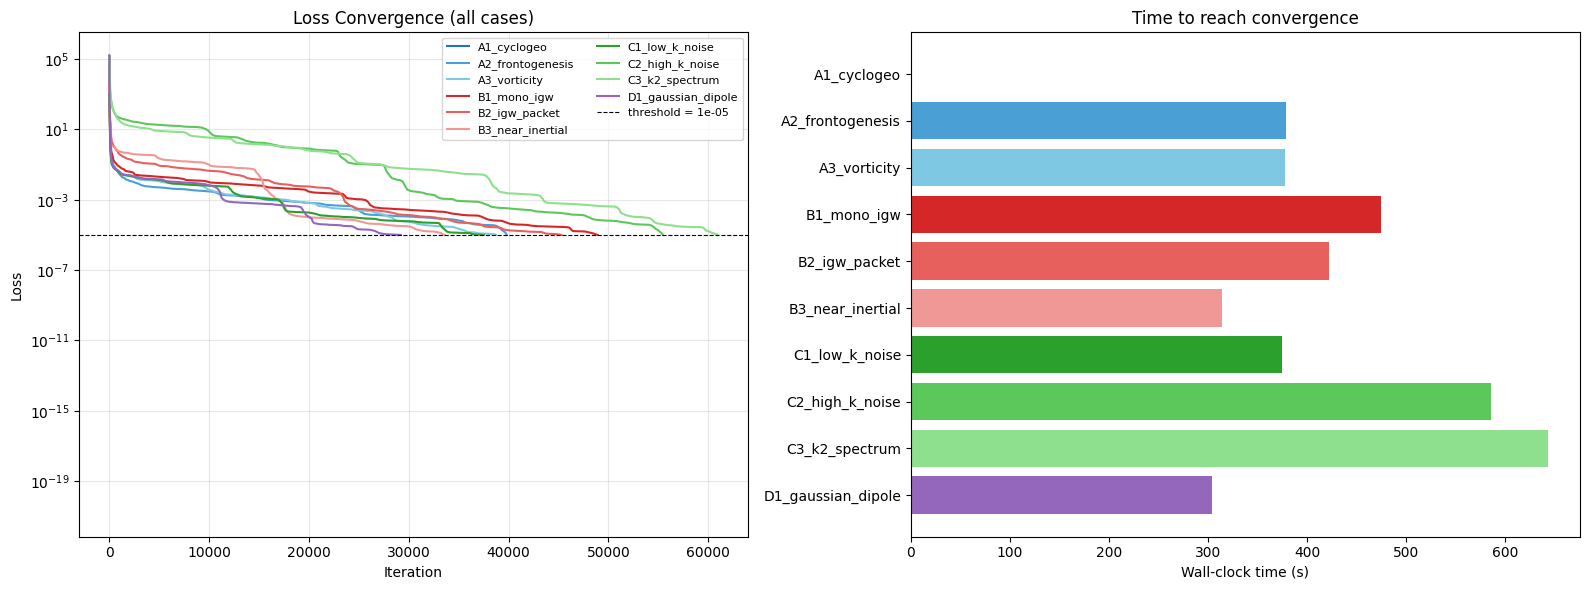

In [72]:
# ── Summary table (with initial loss) ──
print(f"{'Case':<25} {'Init Loss':>14} {'Iters':>7} {'Time (s)':>10} {'Final Loss':>14} {'Final |grad|':>14}")
print("-" * 90)
for name, r in benchmark_results.items():
    init_loss = r['loss_history'][0] if r['loss_history'] else float('nan')
    print(f"{name:<25} {init_loss:>14.4e} {r['iters']:>7d} {r['elapsed']:>10.1f} {r['final_loss']:>14.4e} {r['final_grad']:>14.4e}")

# ── Loss convergence curves (all cases on one plot) ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Colour groups: A=blue shades, B=red shades, C=green shades, D=purple
group_colors = {
    'A1': '#1f77b4', 'A2': '#4a9fd4', 'A3': '#7ec8e3',
    'B1': '#d62728', 'B2': '#e8605d', 'B3': '#f09896',
    'C1': '#2ca02c', 'C2': '#5cc85c', 'C3': '#8ee08e',
    'D1': '#9467bd',
}

for name, r in benchmark_results.items():
    prefix = name[:2]
    color = group_colors.get(prefix, 'gray')
    ax1.semilogy(r['loss_history'], label=name, color=color, linewidth=1.5)

ax1.axhline(loss_threshold, color='k', linestyle='--', linewidth=0.8, label=f'threshold = {loss_threshold:.0e}')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Convergence (all cases)')
ax1.legend(fontsize=8, ncol=2)
# ax1.set_xscale('log')          # ← semi-log: linear x, log y
ax1.grid(True, which='both', alpha=0.3)   # 'both' adds minor grid ticks on log axis


# ── Bar chart: wall-clock time to convergence ──
names  = list(benchmark_results.keys())
times  = [benchmark_results[n]['elapsed'] for n in names]
colors = [group_colors.get(n[:2], 'gray') for n in names]

ax2.barh(names, times, color=colors)
ax2.set_xlabel('Wall-clock time (s)')
ax2.set_title('Time to reach convergence')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

# ── Summary table (with initial loss) ──
print(f"{'Case':<25} {'Init Loss':>14} {'Iters':>7} {'Time (s)':>10} {'Final Loss':>14} {'Final |grad|':>14}")
print("-" * 90)
for name, r in benchmark_results.items():
    init_loss = r['loss_history'][0] if r['loss_history'] else float('nan')
    print(f"{name:<25} {init_loss:>14.4e} {r['iters']:>7d} {r['elapsed']:>10.1f} {r['final_loss']:>14.4e} {r['final_grad']:>14.4e}")

# ── Loss convergence curves (all cases on one plot) ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Colour families: C2_* = blues, C3_* = greens (shade by sweep order)
c2_names = [n for n in benchmark_results if n.startswith("C2_")]
c3_names = [n for n in benchmark_results if n.startswith("C3_")]
blues  = plt.cm.Blues(np.linspace(0.4, 0.95, max(len(c2_names), 1)))
greens = plt.cm.Greens(np.linspace(0.4, 0.95, max(len(c3_names), 1)))
case_colors = {}
for i, n in enumerate(c2_names):
    case_colors[n] = blues[i]
for i, n in enumerate(c3_names):
    case_colors[n] = greens[i]

for name, r in benchmark_results.items():
    color = case_colors.get(name, 'gray')
    ax1.semilogy(r['loss_history'], label=name, color=color, linewidth=1.5)

ax1.axhline(loss_threshold, color='k', linestyle='--', linewidth=0.8, label=f'threshold = {loss_threshold:.0e}')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Convergence (all cases)')
ax1.legend(fontsize=8, ncol=2)
ax1.grid(True, which='both', alpha=0.3)

# ── Bar chart: wall-clock time to convergence ──
names  = list(benchmark_results.keys())
times  = [benchmark_results[n]['elapsed'] for n in names]
colors = [case_colors.get(n, 'gray') for n in names]

ax2.barh(names, times, color=colors)
ax2.set_xlabel('Wall-clock time (s)')
ax2.set_title('Time to reach convergence')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()


Available cases:
  [0] A1_cyclogeo             final_loss = 1.394e-21  |grad| = 8.601e-07
  [1] A2_frontogenesis        final_loss = 9.988e-06  |grad| = 4.747e+00
  [2] A3_vorticity            final_loss = 1.000e-05  |grad| = 4.973e-01
  [3] B1_mono_igw             final_loss = 9.996e-06  |grad| = 9.426e-01
  [4] B2_igw_packet           final_loss = 9.996e-06  |grad| = 8.266e-01
  [5] B3_near_inertial        final_loss = 9.996e-06  |grad| = 1.910e+00
  [6] C1_low_k_noise          final_loss = 9.997e-06  |grad| = 3.879e-01
  [7] C2_high_k_noise         final_loss = 9.933e-06  |grad| = 1.518e+00
  [8] C3_k2_spectrum          final_loss = 9.999e-06  |grad| = 1.159e+00
  [9] D1_gaussian_dipole      final_loss = 9.999e-06  |grad| = 4.978e-01

Plotting: C2_high_k_noise

  rms(target)   = 1.180341e+00
  rms(residual) = 1.923607e-07
  rel error     = 0.0000%


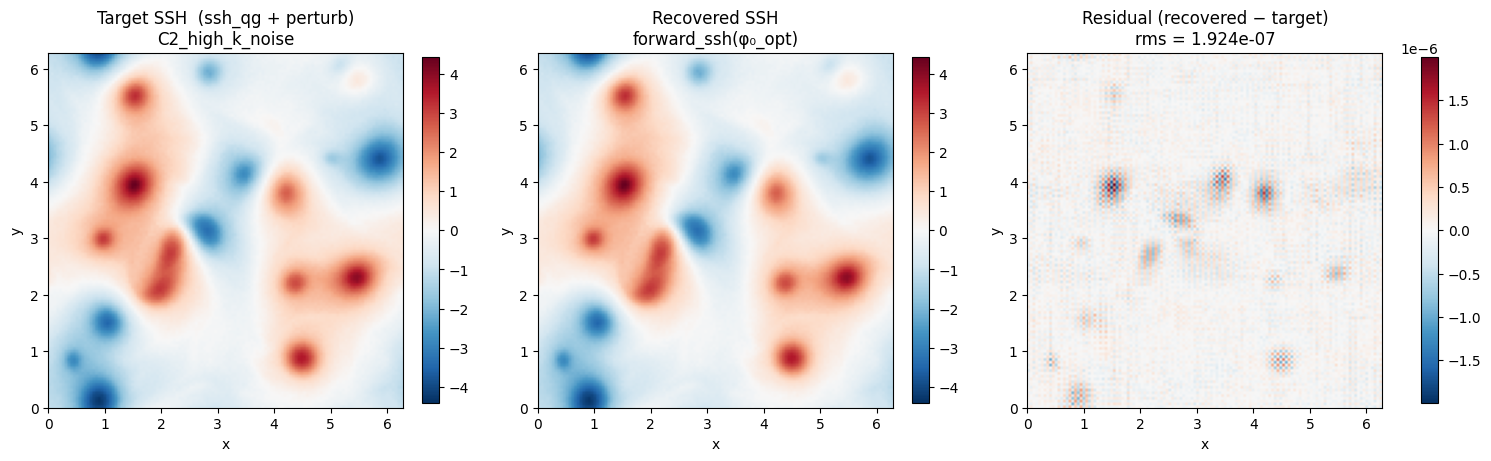

In [73]:
# Pick which case to visualize — change this string to any key in cases
CASE_TO_PLOT = "C2_high_k_noise"

# List available cases so you know what you can choose from
print("Available cases:")
for i, name in enumerate(cases.keys()):
    r = benchmark_results[name]
    print(f"  [{i}] {name:<22}  final_loss = {r['final_loss']:.3e}  |grad| = {r['final_grad']:.3e}")
print(f"\nPlotting: {CASE_TO_PLOT}\n")

perturb, eta_target_phys = cases[CASE_TO_PLOT]      
phi0_opt = phi0_s_optimals[CASE_TO_PLOT]            

# Forward SQG+1 SSH from the optimal streamfunction
phi0_opt_hat   = jnp.fft.fft2(phi0_opt)
eta_opt_hat    = forward_ssh(phi0_opt_hat, kx, ky,
                             mu, inv_mu, K2, inv_K2, Bu, epsilon)
eta_opt_phys   = jnp.real(jnp.fft.ifft2(eta_opt_hat))

residual       = eta_opt_phys - eta_target_phys
rms_target     = float(jnp.sqrt(jnp.mean(eta_target_phys ** 2)))
rms_residual   = float(jnp.sqrt(jnp.mean(residual ** 2)))
rel_err        = rms_residual / rms_target if rms_target > 0 else float('nan')

print(f"  rms(target)   = {rms_target:.6e}")
print(f"  rms(residual) = {rms_residual:.6e}")
print(f"  rel error     = {rel_err:.4%}")

# Code for plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

# Shared colour scale for target / recovered so they're visually comparable
vmax = float(jnp.max(jnp.abs(eta_target_phys)))
im0 = axes[0].imshow(eta_target_phys, origin='lower', cmap='RdBu_r',
                     vmin=-vmax, vmax=vmax,
                     extent=[0, float(Lx), 0, float(Ly)])
axes[0].set_title(f"Target SSH  (ssh_qg + perturb)\n{CASE_TO_PLOT}")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(eta_opt_phys, origin='lower', cmap='RdBu_r',
                     vmin=-vmax, vmax=vmax,
                     extent=[0, float(Lx), 0, float(Ly)])
axes[1].set_title("Recovered SSH\nforward_ssh(φ₀_opt)")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

# Residual on its own scale
rvmax = float(jnp.max(jnp.abs(residual)))
im2 = axes[2].imshow(residual, origin='lower', cmap='RdBu_r',
                     vmin=-rvmax, vmax=rvmax,
                     extent=[0, float(Lx), 0, float(Ly)])
axes[2].set_title(f"Residual (recovered − target)\nrms = {rms_residual:.3e}")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

for ax in axes:
    ax.set_xlabel("x"); ax.set_ylabel("y")

plt.show()


# Pick which case to visualize — change this string to any key in cases
CASE_TO_PLOT = next(iter(cases.keys()))   # default: first case; override with a specific name

# List available cases so you know what you can choose from
print("Available cases:")
for i, name in enumerate(cases.keys()):
    r = benchmark_results[name]
    print(f"  [{i}] {name:<22}  final_loss = {r['final_loss']:.3e}  |grad| = {r['final_grad']:.3e}")
print(f"\nPlotting: {CASE_TO_PLOT}\n")

perturb, eta_target_phys = cases[CASE_TO_PLOT]
phi0_opt = phi0_s_optimals[CASE_TO_PLOT]

# Forward SQG+1 SSH from the optimal streamfunction
phi0_opt_hat   = jnp.fft.fft2(phi0_opt)
eta_opt_hat    = forward_ssh(phi0_opt_hat, kx, ky,
                             mu, inv_mu, K2, inv_K2, Bu, epsilon)
eta_opt_phys   = jnp.real(jnp.fft.ifft2(eta_opt_hat))

residual       = eta_opt_phys - eta_target_phys
rms_target     = float(jnp.sqrt(jnp.mean(eta_target_phys ** 2)))
rms_residual   = float(jnp.sqrt(jnp.mean(residual ** 2)))
rel_err        = rms_residual / rms_target if rms_target > 0 else float('nan')

print(f"  rms(target)   = {rms_target:.6e}")
print(f"  rms(residual) = {rms_residual:.6e}")
print(f"  rel error     = {rel_err:.4%}")

# Code for plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

vmax = float(jnp.max(jnp.abs(eta_target_phys)))
im0 = axes[0].imshow(eta_target_phys, origin='lower', cmap='RdBu_r',
                     vmin=-vmax, vmax=vmax,
                     extent=[0, float(Lx), 0, float(Ly)])
axes[0].set_title(f"Target SSH  (ssh_qg + perturb)\n{CASE_TO_PLOT}")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(eta_opt_phys, origin='lower', cmap='RdBu_r',
                     vmin=-vmax, vmax=vmax,
                     extent=[0, float(Lx), 0, float(Ly)])
axes[1].set_title("Recovered SSH\nforward_ssh(φ₀_opt)")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

rvmax = float(jnp.max(jnp.abs(residual)))
im2 = axes[2].imshow(residual, origin='lower', cmap='RdBu_r',
                     vmin=-rvmax, vmax=rvmax,
                     extent=[0, float(Lx), 0, float(Ly)])
axes[2].set_title(f"Residual (recovered − target)\nrms = {rms_residual:.3e}")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

for ax in axes:
    ax.set_xlabel("x"); ax.set_ylabel("y")

plt.show()


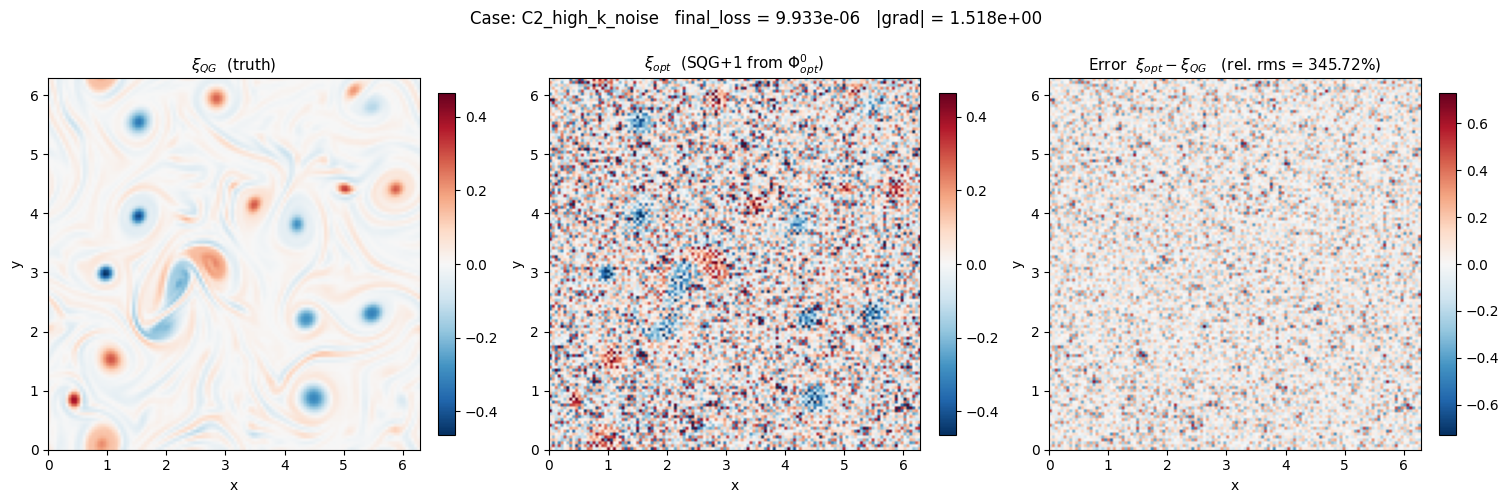

In [74]:
# ── Case selector ──────────────────────────────────────────────────────────────
CASE_TO_PLOT = "C2_high_k_noise"   # change to any key in cases

# ── QG truth vorticity (computed once, same for all cases) ────────────────────
zeta_qg = jnp.real(jnp.fft.ifft2(-K2 * phi0_s_hat))

# ── Per-case recovered vorticity from SQG+1 velocity ─────────────────────────
def compute_zeta_from_phi(phi_hat):
    u, v = calculate_surface_u(phi_hat, mu, inv_mu, kx, ky, K2, inv_K2, epsilon, Bu)
    zeta = jnp.real(jnp.fft.ifft2(
        1j * kx * jnp.fft.fft2(v) - 1j * ky * jnp.fft.fft2(u)
    ))
    return u, v, zeta

# Print summary table for all cases
rms_zeta_qg = float(jnp.sqrt(jnp.mean(zeta_qg**2)))
for name in cases.keys():
    phi_hat = jnp.fft.fft2(phi0_s_optimals[name])
    _, _, zeta_opt = compute_zeta_from_phi(phi_hat)
    rel_err = float(jnp.sqrt(jnp.mean((zeta_opt - zeta_qg)**2))) / rms_zeta_qg

# ── Build fields for the chosen case ──────────────────────────────────────────
phi0_opt_hat = jnp.fft.fft2(phi0_s_optimals[CASE_TO_PLOT])
u_opt, v_opt, zeta_opt = compute_zeta_from_phi(phi0_opt_hat)

zeta_err = zeta_opt - zeta_qg
rel_zeta_err = float(jnp.sqrt(jnp.mean(zeta_err**2))) / rms_zeta_qg

# ── Plot ───────────────────────────────────────────────────────────────────────
extent = [0, float(Lx), 0, float(Ly)]
vmax_z = float(jnp.max(jnp.abs(zeta_qg)))

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

titles = [
    r"$\xi_{QG}$  (truth)",
    r"$\xi_{opt}$  (SQG+1 from $\Phi^0_{opt}$)",
    rf"Error  $\xi_{{opt}} - \xi_{{QG}}$   (rel. rms = {rel_zeta_err:.2%})",
]
fields = [zeta_qg, zeta_opt, zeta_err]

for ax, field, title in zip(axes, fields, titles):
    vmax = vmax_z if "Error" not in title else float(jnp.max(jnp.abs(zeta_err)))
    im = ax.imshow(field, origin='lower', cmap='RdBu_r',
                   vmin=-vmax, vmax=vmax, extent=extent)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    plt.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle(
    f"Case: {CASE_TO_PLOT}   "
    f"final_loss = {benchmark_results[CASE_TO_PLOT]['final_loss']:.3e}   "
    f"|grad| = {benchmark_results[CASE_TO_PLOT]['final_grad']:.3e}",
    fontsize=12
)
plt.show()


# ── Case selector ──────────────────────────────────────────────────────────────
CASE_TO_PLOT = next(iter(cases.keys()))   # change to any key in cases

# ── QG truth vorticity (computed once, same for all cases) ────────────────────
zeta_qg = jnp.real(jnp.fft.ifft2(-K2 * phi0_s_hat))

# ── Per-case recovered vorticity from SQG+1 velocity ─────────────────────────
def compute_zeta_from_phi(phi_hat):
    u, v = calculate_surface_u(phi_hat, mu, inv_mu, kx, ky, K2, inv_K2, epsilon, Bu)
    zeta = jnp.real(jnp.fft.ifft2(
        1j * kx * jnp.fft.fft2(v) - 1j * ky * jnp.fft.fft2(u)
    ))
    return u, v, zeta

rms_zeta_qg = float(jnp.sqrt(jnp.mean(zeta_qg**2)))
for name in cases.keys():
    phi_hat = jnp.fft.fft2(phi0_s_optimals[name])
    _, _, zeta_opt = compute_zeta_from_phi(phi_hat)
    rel_err = float(jnp.sqrt(jnp.mean((zeta_opt - zeta_qg)**2))) / rms_zeta_qg

phi0_opt_hat = jnp.fft.fft2(phi0_s_optimals[CASE_TO_PLOT])
u_opt, v_opt, zeta_opt = compute_zeta_from_phi(phi0_opt_hat)

zeta_err = zeta_opt - zeta_qg
rel_zeta_err = float(jnp.sqrt(jnp.mean(zeta_err**2))) / rms_zeta_qg

extent = [0, float(Lx), 0, float(Ly)]
vmax_z = float(jnp.max(jnp.abs(zeta_qg)))

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

titles = [
    r"$\xi_{QG}$  (truth)",
    r"$\xi_{opt}$  (SQG+1 from $\Phi^0_{opt}$)",
    rf"Error  $\xi_{{opt}} - \xi_{{QG}}$   (rel. rms = {rel_zeta_err:.2%})",
]
fields = [zeta_qg, zeta_opt, zeta_err]

for ax, field, title in zip(axes, fields, titles):
    vmax = vmax_z if "Error" not in title else float(jnp.max(jnp.abs(zeta_err)))
    im = ax.imshow(field, origin='lower', cmap='RdBu_r',
                   vmin=-vmax, vmax=vmax, extent=extent)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    plt.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle(
    f"Case: {CASE_TO_PLOT}   "
    f"final_loss = {benchmark_results[CASE_TO_PLOT]['final_loss']:.3e}   "
    f"|grad| = {benchmark_results[CASE_TO_PLOT]['final_grad']:.3e}",
    fontsize=12
)
plt.show()


In [67]:
import matplotlib.pyplot as plt
import numpy as np

def azimuthal_spectrum(field_2d, K, dk):
    """
    Azimuthal average of a 2D spectral field, binned by integer wavenumber.
    Returns k_integers (1D) and the binned spectrum.
    """
    K_np     = np.array(K)
    field_np = np.array(np.real(field_2d))          # power is real
    k_int    = np.round(K_np / dk).astype(int)       # integer wavenumber index
    k_max    = k_int.max()

    spectrum = np.zeros(k_max + 1)
    counts   = np.zeros(k_max + 1)
    np.add.at(spectrum, k_int.ravel(), field_np.ravel())
    np.add.at(counts,   k_int.ravel(), 1)

    counts   = np.where(counts > 0, counts, np.nan)
    spectrum = spectrum / counts                      # mean power per annulus
    k_axis   = np.arange(k_max + 1)
    return k_axis, spectrum

def spectral_error(phi0_opt_hat, phi0_s_hat, mu, inv_mu, kx, ky,
                   K, K2, inv_K2, epsilon, Bu, dk):
    """
    Azimuthally-averaged relative spectral error in vorticity:

        E(k) = <|ζ̂_opt(k) - ζ̂_qg(k)|²> / <|ζ̂_qg(k)|²>

    ζ_qg  : pure QG truth  =  ifft2(-K² φ̂₀)
    ζ_opt : SQG+1 recovered via calculate_surface_u(φ̂₀_opt)
    """
    # QG truth vorticity (spectral)
    zeta_qg_hat = -K2 * phi0_s_hat

    # SQG+1 recovered vorticity (spectral)
    u_opt, v_opt = calculate_surface_u(phi0_opt_hat, mu, inv_mu,
                                       kx, ky, K2, inv_K2, epsilon, Bu)
    zeta_opt_hat = 1j * kx * jnp.fft.fft2(v_opt) - 1j * ky * jnp.fft.fft2(u_opt)

    err_power    = jnp.abs(zeta_opt_hat - zeta_qg_hat) ** 2
    signal_power = jnp.abs(zeta_qg_hat) ** 2

    k_axis, err_spec    = azimuthal_spectrum(err_power,    K, dk)
    _,      signal_spec = azimuthal_spectrum(signal_power, K, dk)

    # Relative error; NaN where signal is negligible
    with np.errstate(invalid='ignore', divide='ignore'):
        rel_spec = np.where(signal_spec > 1e-30, err_spec / signal_spec, np.nan)

    return k_axis, err_spec, signal_spec, rel_spec

# ── dk from the simulation grid ───────────────────────────────────────────────
dk = float(2.0 * jnp.pi / Nx)    # matches how kx/ky are built in spectral_main.py

# ── QG signal spectrum (reference, same for every case) ───────────────────────
zeta_qg_hat  = -K2 * phi0_s_hat
k_axis, signal_spec = azimuthal_spectrum(jnp.abs(zeta_qg_hat)**2, K, dk)

# ── Plot ───────────────────────────────────────────────────────────────────────
CASES_TO_PLOT = list(cases.keys())

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
ax_abs, ax_rel = axes

for name in CASES_TO_PLOT:
    phi0_opt_hat = jnp.fft.fft2(phi0_s_optimals[name])
    k_axis, err_spec, _, rel_spec = spectral_error(
        phi0_opt_hat, phi0_s_hat, mu, inv_mu,
        kx, ky, K, K2, inv_K2, epsilon, Bu, dk
    )
    ax_abs.semilogy(k_axis, err_spec,  label=name)
    ax_rel.semilogy(k_axis, rel_spec,  label=name)

for ax in axes:
    ax.set_xlabel("wavenumber k  (grid units)")
    ax.set_xlim(1, Nx // 2)
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=8)

ax_abs.set_ylabel(r"$\langle\,|\hat{\zeta}_{opt} - \hat{\zeta}_{QG}|^2\rangle$")
ax_abs.set_title("Absolute spectral error in vorticity")

ax_rel.set_ylabel(r"$E(k) = \langle|\Delta\hat{\zeta}|^2\rangle\,/\,\langle|\hat{\zeta}_{QG}|^2\rangle$")
ax_rel.set_title("Relative spectral error in vorticity")
ax_rel.axhline(1.0, color='k', ls='--', lw=1, label='100% error')
ax_rel.legend(fontsize=8)

fig.suptitle("Spectral error decomposition: inversion skill by wavenumber", fontsize=13)
plt.show()


C:\Users\lijin\AppData\Local\Temp\ipykernel_43920\3131600359.py:91: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [ ]:
import dill

to_save = {
    'benchmark_results': benchmark_results,
    'phi0_s_optimals':   phi0_s_optimals,
    'cases':             cases,
    'phi0_s':            phi0_s,
    'phi0_s_hat':        phi0_s_hat,
    'kx': kx, 'ky': ky, 'K': K, 'K2': K2, 'inv_K2': inv_K2,
    'mu': mu, 'inv_mu': inv_mu,
    'Ro': Ro, 'epsilon': epsilon, 'Bu': Bu,
    'Nx': Nx, 'Ny': Ny, 'Lx': Lx, 'Ly': Ly,
    'X': X, 'Y': Y,
}
with open('workspace_0412_afternoon.pkl', 'wb') as f:
    dill.dump(to_save, f)
